# 2D FEM: Straight vs. Bent Didgeridoo

This notebook runs the 2D FEM acoustic simulation on the same bore geometry
twice:
1. **Straight** — the centerline is the x-axis.
2. **Bent** — the centerline follows the curve in
   `src/experiments/2dfem/curve.csv` (planar polyline in the Y–Z plane).

Both impedance spectra are plotted alongside images of the two FEM meshes.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from didgelab.geo import Geo
from didgelab.sim.fem2d import FiniteElementsModeling2D, build_2d_mesh
from didgelab.sim.sim_interface import AcousticConstants

# Notebook now lives in src/experiments/2dfem/ alongside geo.json and curve.csv.
EXP_DIR = Path.cwd()
if not (EXP_DIR / 'geo.json').exists():
    # Fallback when launched from the repo root
    EXP_DIR = (Path.cwd() / 'doc' / 'examples' / 'bent_shapes').resolve()
print('experiments dir:', EXP_DIR)

experiments dir: /Users/jannehring/workspaces/music/didgitaldoo/workspace/didge-lab/src/experiments/2dfem


## Load geometry and centerline

In [2]:
with open(EXP_DIR / 'geo.json') as f:
    geo_list = json.load(f)
geo = Geo(geo_list)
geo_arr = np.array(geo.geo)
bore_length_mm = float(geo_arr[-1, 0] - geo_arr[0, 0])
print(f'bore length: {bore_length_mm:.1f} mm, '
      f'mouth d: {geo_arr[0,1]:.1f} mm, bell d: {geo_arr[-1,1]:.1f} mm, '
      f'{len(geo_arr)} segments')

bore length: 1712.3 mm, mouth d: 32.0 mm, bell d: 90.7 mm, 36 segments


In [3]:
# Centerline in row order; X is essentially constant so use (Y, Z) as planar coords.
curve_df = pd.read_csv(EXP_DIR / 'curve.csv')
centerline_m = curve_df[['Y', 'Z']].values  # metres
centerline_mm = centerline_m * 1000.0
arc_mm = np.linalg.norm(np.diff(centerline_mm, axis=0), axis=1).sum()
print(f'centerline arc length: {arc_mm:.1f} mm  (bore: {bore_length_mm:.1f} mm)')

centerline arc length: 1700.9 mm  (bore: 1712.3 mm)


## Inspect the raw curve

Before building the bent mesh, look at the centerline's actual shape.
The bell of the didge gets extruded perpendicular to the local tangent,
so any **sharp turn** in the curve (turning radius < d/2) will cause the
strip to overlap itself near the bell.

Scaling the curve uniformly can *only* fix length problems, not shape
ones — if the curve loops back on itself the wrap is geometric and
scaling won't remove it. Use **`CURVE_END_FRAC`** below to truncate
the curve before any loop-back, and **`CURVE_SCALE`** for fine length
adjustment after that.

## Plot the two meshes

using first 194/194 curve points (100.0%)
bore length        : 1712.3 mm
bent spine arc len : 1711.0 mm  (= 0.999 x bore length)


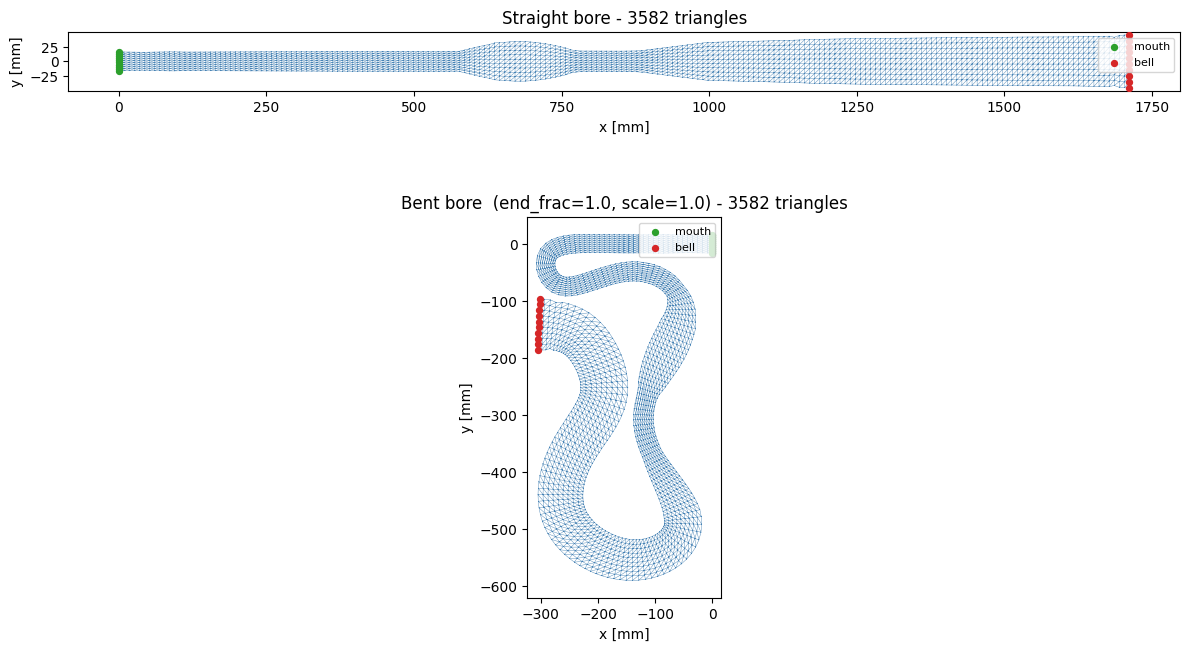

In [4]:
N_AXIAL = 200
N_RADIAL = 10

# --- Centerline trimming and scaling ----------------------------------
# CURVE_END_FRAC: fraction of the raw curve to KEEP (from the start).
#   The curve in curve.csv loops back on itself near row 192/201 (a 180-
#   degree turn), which causes the bell strip to overlap itself. Set this
#   below ~0.95 to drop the loop-back.
# CURVE_SCALE: multiplier on bore length for the trimmed centerline's
#   target arc length. 1.0 = arc length == bore length.
CURVE_END_FRAC = 1.0
CURVE_SCALE    = 1.0
# 'centerline' (legacy) scales the centerline arc to bore length.
# 'mean_wall' scales so (inner+outer)/2 wall arc == bore length, which
# removes the bend-induced length bias that pulls the bent fundamental
# below the straight one.
LENGTH_BASIS   = 'mean_wall'
# Bent-tube wavefront shortcut: parameter-free correction that scales
# the local squared wavenumber by (ds_inner_wall / ds_centerline)^2.
# Set to False to disable (recovers the bare axisymmetric solve).

_n = len(centerline_mm)
_keep = max(2, int(round(_n * CURVE_END_FRAC)))
centerline_used = centerline_mm[:_keep]
print(f'using first {_keep}/{_n} curve points ({100*_keep/_n:.1f}%)')

# Build meshes for visualisation only. We pass full_strip=True so both
# sides of the centerline appear in the plot, matching the visual
# intuition of a tube cross-section. The impedance solver below uses
# the axisymmetric half-strip internally (see fem2d.fem2d).
mesh_str, pts_str, mouth_str, bell_str, _r_str = build_2d_mesh(
    geo_arr, n_axial=N_AXIAL, n_radial=N_RADIAL,
    centerline=None, full_strip=True,
)
mesh_bent, pts_bent, mouth_bent, bell_bent, _r_bent = build_2d_mesh(
    geo_arr, n_axial=N_AXIAL, n_radial=N_RADIAL,
    centerline=centerline_used, centerline_scale=CURVE_SCALE,
    length_basis=LENGTH_BASIS, full_strip=True,
)

# Report the resulting arc length of the spine for sanity check.
mid = N_RADIAL // 2
_bent_spine = pts_bent.reshape(N_AXIAL, N_RADIAL, 2)[:, mid, :]
_spine_arc = float(np.linalg.norm(np.diff(_bent_spine, axis=0), axis=1).sum())
print(f'bore length        : {bore_length_mm:.1f} mm')
print(f'bent spine arc len : {_spine_arc:.1f} mm  '
      f'(= {_spine_arc/bore_length_mm:.3f} x bore length)')

def _plot_mesh(ax, mesh, points, mouth_nodes, bell_nodes, title):
    p = mesh.p
    t = mesh.t
    ax.triplot(p[0], p[1], t.T, linewidth=0.3, color='steelblue')
    ax.scatter(points[mouth_nodes, 0], points[mouth_nodes, 1], s=18,
               color='tab:green', label='mouth', zorder=3)
    ax.scatter(points[bell_nodes, 0], points[bell_nodes, 1], s=18,
               color='tab:red', label='bell', zorder=3)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')
    ax.legend(loc='upper right', fontsize=8)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
_plot_mesh(axes[0], mesh_str, pts_str, mouth_str, bell_str,
           f'Straight bore - {mesh_str.t.shape[1]} triangles')
_plot_mesh(axes[1], mesh_bent, pts_bent, mouth_bent, bell_bent,
           f'Bent bore  (end_frac={CURVE_END_FRAC}, scale={CURVE_SCALE}) '
           f'- {mesh_bent.t.shape[1]} triangles')
plt.tight_layout()
plt.show()

## Run the 2D FEM impedance sweep

In [5]:
from didgelab import get_log_simulation_frequencies

freqs = get_log_simulation_frequencies()
constants = AcousticConstants()  # explicit default; base ABC also accepts None

sim_straight = FiniteElementsModeling2D(
    constants=constants, centerline=None,
    n_axial=N_AXIAL, n_radial=N_RADIAL,
)
sim_bent = FiniteElementsModeling2D(
    constants=constants, centerline=centerline_used,
    centerline_scale=CURVE_SCALE, length_basis=LENGTH_BASIS,
    n_axial=N_AXIAL, n_radial=N_RADIAL,
)

imp_straight = sim_straight.get_impedance_spectrum(geo, freqs)
imp_bent = sim_bent.get_impedance_spectrum(geo, freqs)
print('done; peak (straight):', freqs[int(np.argmax(imp_straight))], 'Hz')
print('done; peak (bent)    :', freqs[int(np.argmax(imp_bent))], 'Hz')

done; peak (straight): 73.86866480069497 Hz
done; peak (bent)    : 76.03318189722374 Hz


## Compare impedance spectra

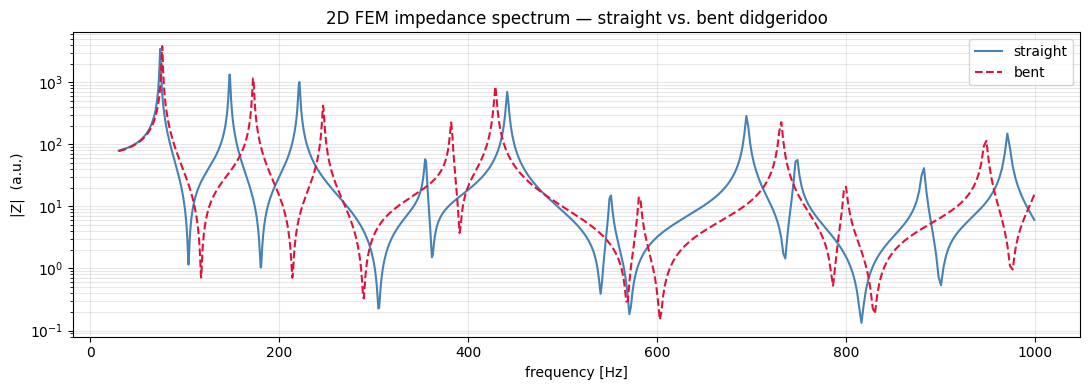

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(freqs, imp_straight, label='straight', color='steelblue')
ax.plot(freqs, imp_bent, label='bent', color='crimson', linestyle='--')
ax.set_xlabel('frequency [Hz]')
ax.set_ylabel('|Z|  (a.u.)')
ax.set_yscale('log')
ax.set_title('2D FEM impedance spectrum — straight vs. bent didgeridoo')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

Notes:
* The 2D FEM treats the bore as a planar channel in the meridional plane,
  so the straight case is an axisymmetric approximation while the bent case
  models the curvature directly.
* `centerline_mm` is the (Y, Z) polyline from `curve.csv`, scaled internally
  so its arc length equals the bore length.
* Increase `N_AXIAL` / `N_RADIAL` for higher accuracy at the cost of compute.

In [7]:
# compute the first 5 harmonics of straight and bent diff and the difference in cent between them

from scipy.signal import argrelmax
from didgelab import cent_diff

data = pd.DataFrame({
    "straight_f": freqs[argrelmax(imp_straight)][0:5],
    "bent_f": freqs[argrelmax(imp_bent)][0:5],
})
data['cent_diff'] = [cent_diff(f_straight, f_bent) for f_straight, f_bent in zip(data.straight_f, data.bent_f)]

data.round(2)

,straight_f,bent_f,cent_diff
0,73.87,76.03,50.0
1,147.31,172.17,270.0
2,221.36,246.32,185.0
3,354.44,382.08,130.0
4,441.44,428.87,-50.0
